<a href="https://colab.research.google.com/github/inhyuk78/Pneumonia-Prediction-Model-using-PneumoniaMNIST-database/blob/main/Pneumonia_Prediction_Model_using_PneumoniaMNIST_database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
pip install medmnist

In [59]:
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image

##**Data Preparation**

In [60]:
transform = transforms.ToTensor()

train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
val_dataset = PneumoniaMNIST(split='val', transform=transform, download=True)
test_dataset = PneumoniaMNIST(split='test', transform=transform, download=True)
print(f'Train dataset: {len(train_dataset)}, Val dataset: {len(val_dataset)}, Test dataset: {len(test_dataset)}, Total: {len(train_dataset) + len(test_dataset) + len(val_dataset)}')

img, label = val_dataset[0]
print(img.shape)

Train dataset: 4708, Val dataset: 524, Test dataset: 624, Total: 5856
torch.Size([1, 28, 28])


In [61]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

##**Model Architecture**

In [62]:
class MultiLayerModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        # Block 1
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 28x28 -> 14x14

        # Block 2
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),  # 14x14 -> 7x7

        # Flatten + Binary Classification
        nn.Flatten(),
        nn.Linear(in_features=32 * 7 * 7, out_features=64),
        nn.ReLU(),
        nn.Linear(64,1)  # Binary classification as loss_fn (= BCEWithLogitsLoss)
    )

  def forward(self,x):
    return self.network(x)

model = MultiLayerModel()
print(model)

MultiLayerModel(
  (network): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1568, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)


##**Model Training**

In [63]:
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.BCEWithLogitsLoss()

def train_one_epoch(model, train_loader, loss_fn, optimizer):
  model.train()
  epoch_loss = 0

  for imgs,labels in train_loader:
    X_train = imgs.float()
    y_train =labels.view(-1,1).float()

    y_hat = model(X_train)
    loss = loss_fn(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  return epoch_loss / len(train_loader)

def train_model(model, train_loader, loss_fn, optimizer, epochs):
  losses = []

  for epoch in range(epochs):
    epoch_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
    losses.append(epoch_loss)

    if epoch % 10 == 0:
      print(f'Epoch {epoch}: Loss = {epoch_loss:.4f}')

  return losses

losses = train_model(model, train_loader, loss_fn, optimizer, epochs=100)

Epoch 0: Loss = 0.4829
Epoch 10: Loss = 0.0993
Epoch 20: Loss = 0.0749
Epoch 30: Loss = 0.0651
Epoch 40: Loss = 0.0482
Epoch 50: Loss = 0.0333
Epoch 60: Loss = 0.0214
Epoch 70: Loss = 0.0128
Epoch 80: Loss = 0.0047
Epoch 90: Loss = 0.0020


##**Training Loss vs Epochs**

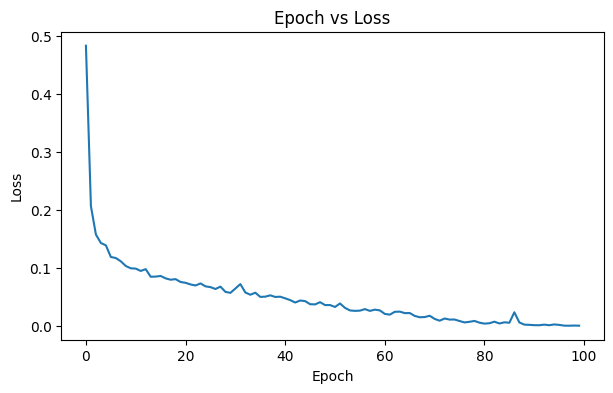

In [64]:
def plot_loss(losses):
  plot = plt.figure(figsize=(7,4))
  plt.plot(losses)

  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Epoch vs Loss')
  return plt.show()

plot_loss(losses)

##**Model Performance Evaluation (Validation Set)**

In [65]:
def val_model(model, val_loader):
  all_preds = []
  all_labels = []

  model.eval()

  with torch.no_grad():
    for imgs,labels in val_loader:
      X_val = imgs.float()
      y_val = labels.view(-1,1).float()

      y_pred_logits = model(X_val)
      y_pred_probs = torch.sigmoid(y_pred_logits)
      y_pred = (y_pred_probs >= 0.5).float()

      all_preds.append(y_pred)
      all_labels.append(y_val)

    all_preds = torch.concat(all_preds)
    all_labels = torch.concat(all_labels)

    accuracy = (all_preds == all_labels).float().mean()
    return f'Accuracy (Validation Set): {accuracy.item():.4f}'

val_model(model, val_loader)

'Accuracy (Validation Set): 0.9618'

##**Model Performance Evaluation (Test Set)**

In [66]:
def test_model(model, test_loader):
  all_preds = []
  all_labels = []

  model.eval()

  with torch.no_grad():
    for imgs,labels in test_loader:
      X_test = imgs.float()
      y_test = labels.view(-1,1).float()

      y_pred_logits = model(X_test)
      y_pred_probs = torch.sigmoid(y_pred_logits)
      y_pred = (y_pred_probs >= 0.5).float()

      all_preds.append(y_pred)
      all_labels.append(y_test)

    all_preds = torch.concat(all_preds)
    all_labels = torch.concat(all_labels)

    accuracy = (all_preds == all_labels).float().mean()
    return f'Accuracy (Test Set): {accuracy.item():.4f}'

test_model(model, test_loader)

'Accuracy (Test Set): 0.8750'

##**Model Evaluation on External Chest X-ray Images**

In [67]:
def img_resizing(filepath):
  img = Image.open(filepath)
  img_resized = img.resize((28,28)).convert('L')  # converting to grayscale
  return img_resized

In [68]:
def img_to_tensor(img_resized):
  img_tensor = transform(img_resized)
  img_tensor = img_tensor.unsqueeze(0)
  return img_tensor

In [69]:
def sample_test_model(img_tensor, label):
  model.eval()

  with torch.no_grad():
    logit = model(img_tensor)
    prob = torch.sigmoid(logit)
    pred = 'Pneumonia' if prob >= 0.5 else 'Normal'
    actual = 'Pneumonia' if label >= 0.5 else 'Normal'

  return f'Sample Prediction = {pred}, Actual = {actual}'

Sample Prediction = Pneumonia, Actual = Pneumonia


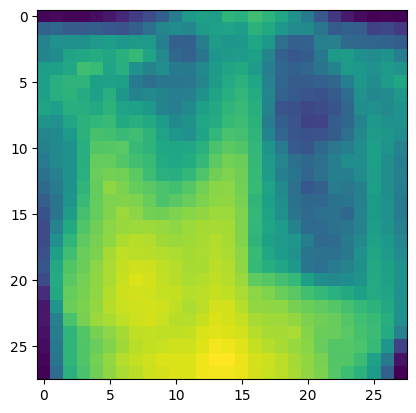

In [74]:
# Test 1 (Pneumonia)

img_resized = img_resizing('pneumonia3.png')
img_tensor = img_to_tensor(img_resized)

plt.imshow(img_resized)
print(sample_test_model(img_tensor, 1))

Sample Prediction = Normal, Actual = Pneumonia


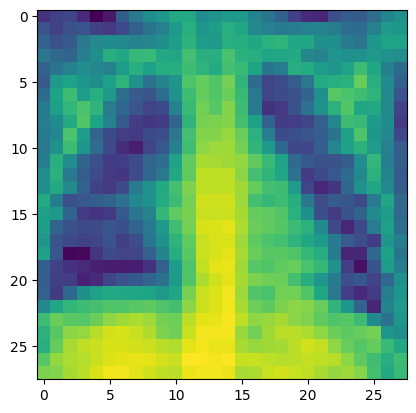

In [71]:
# Test 2 (Pneumonia)

img_resized = img_resizing('pneumonia2.png')
img_tensor = img_to_tensor(img_resized)

plt.imshow(img_resized)
print(sample_test_model(img_tensor, 1))

Sample Prediction = Normal, Actual = Normal


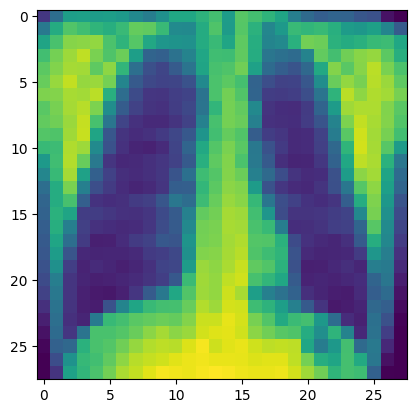

In [72]:
# Test 3 (Normal)

img_resized = img_resizing('normal1.jpg')
img_tensor = img_to_tensor(img_resized)

plt.imshow(img_resized)
print(sample_test_model(img_tensor, 0))

Sample Prediction = Normal, Actual = Normal


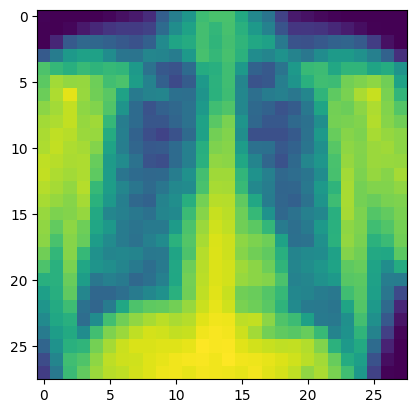

In [73]:
# Test 4 (Normal)

img_resized = img_resizing('normal2.jpeg')
img_tensor = img_to_tensor(img_resized)

plt.imshow(img_resized)
print(sample_test_model(img_tensor, 0))